# Module 3 Post-Fire Recovery
Tracks vegetation recovery in the Cameron Peak burn scar over the growing
seasons following the fire, and flags where recovery is lagging; a leading
indicator of continued erosion/watershed risk.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import daear_toolkit as dt
from daear_toolkit import data_access, indicators, cube, viz

REGION = dt.POUDRE_CAMERON_PEAK
BBOX = REGION.bbox

# Post-fire growing-season scenes across three years
recovery_dates = ["2021-07-01", "2022-07-01", "2023-07-01"]
scenes = {d: data_access.get_optical_scene(BBOX, d, seed=300 + i) for i, d in enumerate(recovery_dates)}
ndvi_cube = cube.stack_time_series(scenes, indicators.ndvi)
ndvi_cube.name = "ndvi"
ndvi_cube

<xarray.DataArray 'ndvi' (time: 3, lat: 151, lon: 200)> Size: 362kB
array([[[0.45733002, 0.5709483 , 0.61473787, ..., 0.6923569 ,
         0.68327045, 0.7389413 ],
        [0.5060785 , 0.57308227, 0.6130428 , ..., 0.65675455,
         0.62963617, 0.72117114],
        [0.431211  , 0.5365625 , 0.5726457 , ..., 0.6589501 ,
         0.65396196, 0.72228944],
        ...,
        [0.708737  , 0.64660853, 0.6834972 , ..., 0.48790264,
         0.4872447 , 0.42076057],
        [0.6753156 , 0.64015716, 0.6561039 , ..., 0.4777005 ,
         0.4814826 , 0.45402798],
        [0.66097987, 0.61803055, 0.6738939 , ..., 0.5133382 ,
         0.52015334, 0.4982215 ]],

       [[0.4087199 , 0.5734239 , 0.52336043, ..., 0.50339025,
         0.42978972, 0.48884755],
        [0.3392965 , 0.45509076, 0.42688772, ..., 0.4193791 ,
         0.36760706, 0.38646626],
        [0.21466194, 0.35851017, 0.3613759 , ..., 0.4509256 ,
         0.4001961 , 0.4269203 ],
...
        [0.45951125, 0.5184262 , 0.50434005, ..., 0.598267  ,
         0.49278006, 0.52960986],
        [0.4799399 , 0.4924112 , 0.47987276, ..., 0.6154975 ,
         0.5157466 , 0.5386408 ],
        [0.4515371 , 0.49504867, 0.46225804, ..., 0.59580475,
         0.51191777, 0.5577314 ]],

       [[0.47191948, 0.54615647, 0.5896628 , ..., 0.42787322,
         0.44380388, 0.32686478],
        [0.539319  , 0.57694584, 0.60458565, ..., 0.4677539 ,
         0.47852764, 0.35653266],
        [0.57401043, 0.6099433 , 0.6304453 , ..., 0.53896636,
         0.5059117 , 0.46228886],
        ...,
        [0.5396094 , 0.5220846 , 0.5479881 , ..., 0.5625202 ,
         0.5801357 , 0.5944181 ],
        [0.4585492 , 0.43388006, 0.49936107, ..., 0.5349502 ,
         0.55875057, 0.55404544],
        [0.44055453, 0.42570347, 0.47089878, ..., 0.52692544,
         0.5916157 , 0.5442478 ]]], shape=(3, 151, 200), dtype=float32)
Coordinates:
  * time     (time) <U10 120B '2021-07-01' '2022-07-01' '2023-07-01'
  * lat      (lat) float64 1kB 40.55 40.55 40.55 40.56 ... 40.85 40.85 40.85
  * lon      (lon) float64 2kB -105.8 -105.8 -105.8 ... -105.5 -105.5 -105.5
Attributes:
    description:  Normalized Difference Vegetation Index

## Vegetation recovery trajectory

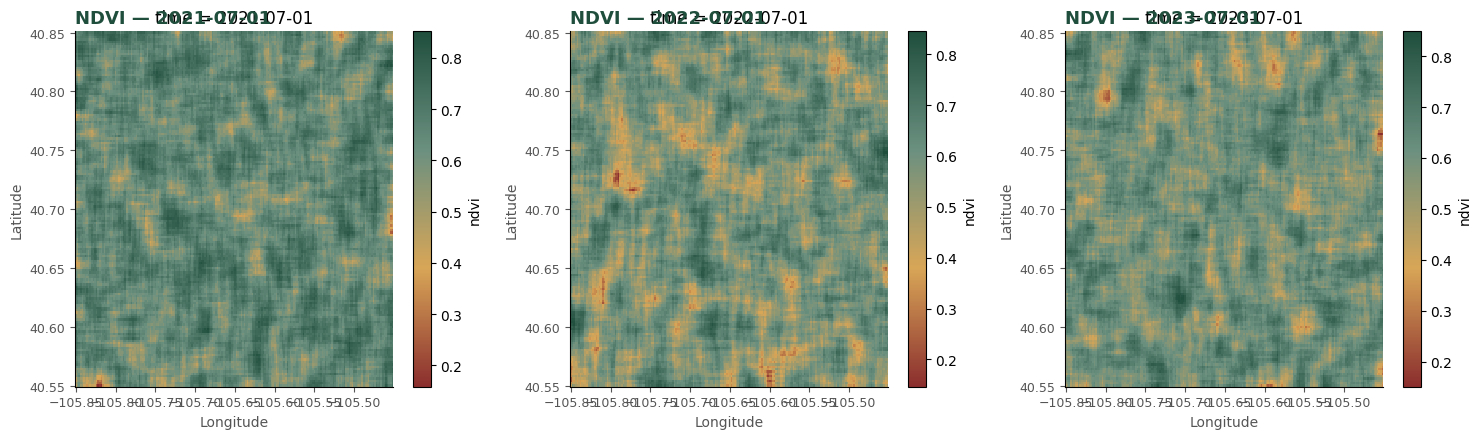

2021-07-01: mean NDVI = 0.649
2022-07-01: mean NDVI = 0.581
2023-07-01: mean NDVI = 0.605


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for i, d in enumerate(recovery_dates):
    viz.plot_raster(ndvi_cube.sel(time=d), title=f"NDVI — {d}", ax=axes[i])
plt.tight_layout()
plt.savefig("../outputs/03_recovery_trajectory.png", dpi=150)
plt.show()

mean_by_year = ndvi_cube.mean(dim=["lat", "lon"])
for d, val in zip(recovery_dates, mean_by_year.values):
    print(f"{d}: mean NDVI = {val:.3f}")

## Recovery rate relative to burn severity

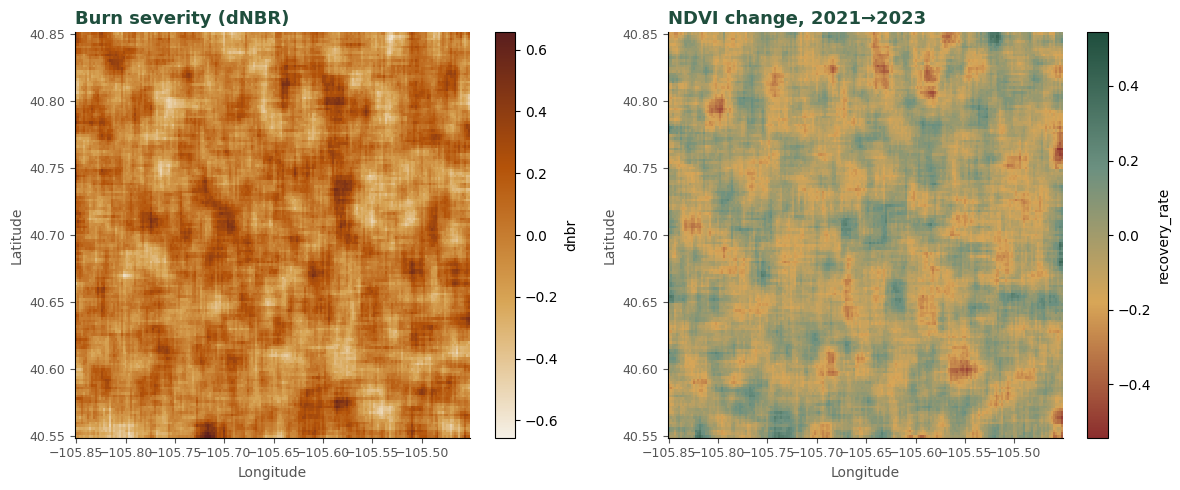

Correlation between burn severity and recovery rate: -0.02
(Sign/magnitude are artifacts of the synthetic generator here; the
 pipeline is what matters — this is exactly the check a real deployment runs.)


In [3]:
pre_scene = data_access.get_optical_scene(BBOX, "2020-06-01", seed=100)
post_scene = data_access.get_optical_scene(BBOX, "2020-10-15", seed=200)
burn = indicators.dnbr(pre_scene, post_scene)

recovery_rate = (ndvi_cube.isel(time=-1) - ndvi_cube.isel(time=0))
recovery_rate.name = "recovery_rate"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
viz.plot_raster(burn, title="Burn severity (dNBR)", ax=axes[0], cmap=viz.SEVERITY_CMAP)
viz.plot_raster(recovery_rate, title="NDVI change, 2021→2023", ax=axes[1])
plt.tight_layout()
plt.savefig("../outputs/03_recovery_vs_severity.png", dpi=150)
plt.show()

corr = np.corrcoef(burn.values.flatten(), recovery_rate.values.flatten())[0, 1]
print(f"Correlation between burn severity and recovery rate: {corr:.2f}")
print("(Sign/magnitude are artifacts of the synthetic generator here; the")
print(" pipeline is what matters — this is exactly the check a real deployment runs.)")

## Summary

Areas with high burn severity *and* slow NDVI recovery are the ones most
likely to still be contributing sediment and runoff years after the fire 
this feeds directly into Module 4's risk dashboard and into
`soil-watershed-intelligence`'s restoration-monitoring module.
